# Resource monitor: memory over time vs. task boundaries

Plots `vmstat.<JOB_TAG>.log` (written by `run_reference_dynamics.sh`) against the
Parsl task-completion timestamps for the matching `runinfo/<run>/parsl.log`, so a
memory blowup can be read against which trajectory was executing at the time.

Set `JOB_TAG` and `RUNINFO_DIR` below and re-run for any job.

In [5]:
cd runinfo

[Errno 2] No such file or directory: 'runinfo'
/home/michael/repos/cascade/3_cascade/runinfo


In [8]:
import re
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

JOB_TAG = "20260806-213421"
RUNINFO_DIR = Path("runinfo/029")  # runinfo/<run> dir whose parsl.log covers this job

VMSTAT_LOG = Path(f"vmstat.{JOB_TAG}.log")
PARSL_LOG = RUNINFO_DIR / "parsl.log"

In [9]:
def load_vmstat(path: Path) -> pd.DataFrame:
    """Parse a `vmstat -SM -t` log into a dataframe, skipping the repeated header lines."""
    cols = ["r", "b", "swpd", "free", "buff", "cache", "si", "so",
            "bi", "bo", "in", "cs", "us", "sy", "idle", "wa", "st", "gu"]
    row_re = re.compile(
        r"^\s*" + r"\s+".join([r"(\d+)"] * len(cols)) +
        r"\s+(\d{4}-\d{2}-\d{2})\s+(\d{2}:\d{2}:\d{2})\s*$"
    )
    rows = []
    for line in path.read_text().splitlines():
        m = row_re.match(line)
        if not m:
            continue  # header line ("procs ..." / " r  b ...")
        *vals, date, time = m.groups()
        rec = dict(zip(cols, (int(v) for v in vals)))
        rec["timestamp"] = pd.Timestamp(f"{date} {time}")
        rows.append(rec)
    df = pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)
    return df


vmstat = load_vmstat(VMSTAT_LOG)
vmstat.head()

,r,b,swpd,free,buff,cache,si,so,bi,bo,in,cs,us,sy,idle,wa,st,gu,timestamp
0,4,0,0,91196,411,28015,0,0,1804,451,158972,175,2,4,94,0,0,0,2026-08-06 21:34:21
1,3,0,0,90122,411,28064,0,0,0,123,216035,443980,8,6,86,0,0,0,2026-08-06 21:34:26
2,3,0,0,89246,411,28064,0,0,0,58,205457,402132,7,6,86,0,0,0,2026-08-06 21:34:31
3,84,0,0,84654,411,28070,0,0,0,61,190867,791718,25,11,64,0,0,0,2026-08-06 21:34:36
4,84,0,0,84216,411,28065,0,0,0,166,134865,5351726,53,44,4,0,0,0,2026-08-06 21:34:41


In [10]:
def load_task_boundaries(path: Path) -> pd.DataFrame:
    """Pull Parsl task-completion timestamps ('... to exec_done') out of parsl.log.

    Completion events (not launch events) are used as boundaries: with
    max_workers=1 all tasks are \"launched\" into the queue almost simultaneously,
    but only one runs at a time, so exec_done marks when the *next* task actually
    starts executing.
    """
    event_re = re.compile(
        r"^\S+ (\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}) .*"
        r"Task (\d+) changing state from launched to exec_done"
    )
    events = []
    for line in path.read_text().splitlines():
        m = event_re.match(line)
        if m:
            ts, task_id = m.groups()
            events.append({"timestamp": pd.Timestamp(ts), "task_id": int(task_id)})
    return pd.DataFrame(events).sort_values("timestamp").reset_index(drop=True)


task_boundaries = load_task_boundaries(PARSL_LOG)
task_boundaries

,timestamp,task_id
0,2026-08-06 22:38:27,0
1,2026-08-06 23:25:50,1


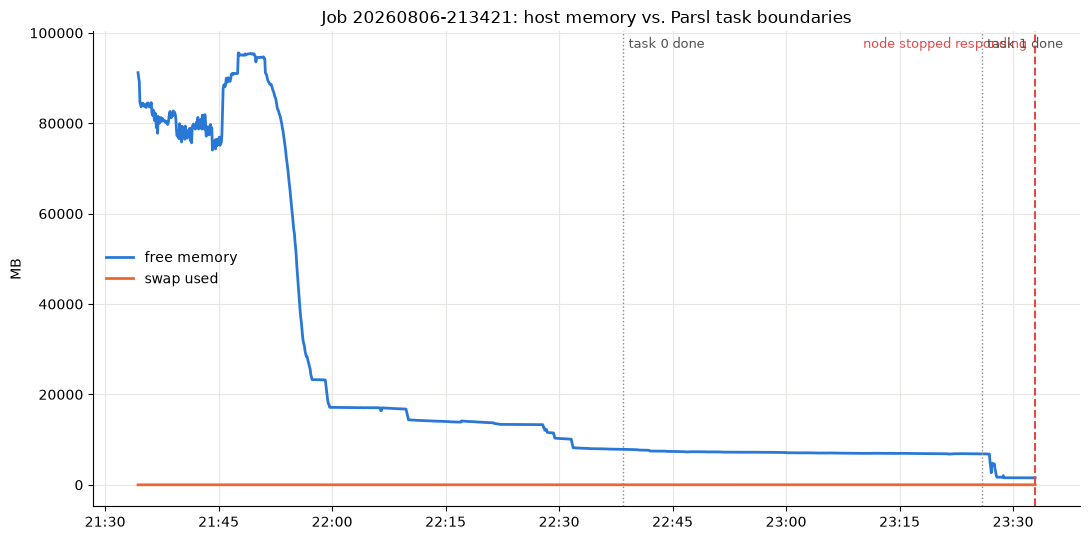

In [11]:
# Reference palette (see dataviz skill): blue = primary series, orange = secondary,
# red = critical/crash marker, muted gray = boundary/annotation ink.
COLOR_FREE = "#2a78d6"
COLOR_SWAP = "#eb6834"
COLOR_CRASH = "#e34948"
COLOR_BOUNDARY = "#8a8a86"
COLOR_TEXT = "#52514e"

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(vmstat["timestamp"], vmstat["free"], color=COLOR_FREE, linewidth=2, label="free memory")
ax.plot(vmstat["timestamp"], vmstat["swpd"], color=COLOR_SWAP, linewidth=2, label="swap used")

# node death: last sample the monitor managed to write
crash_ts = vmstat["timestamp"].iloc[-1]
ax.axvline(crash_ts, color=COLOR_CRASH, linewidth=1.5, linestyle="--")
ax.annotate(
    "node stopped responding", xy=(crash_ts, ax.get_ylim()[1]),
    xytext=(-6, -4), textcoords="offset points", ha="right", va="top",
    color=COLOR_CRASH, fontsize=9,
)

# task boundaries
for _, row in task_boundaries.iterrows():
    ax.axvline(row["timestamp"], color=COLOR_BOUNDARY, linewidth=1, linestyle=":")
    ax.annotate(
        f"task {row['task_id']} done", xy=(row["timestamp"], ax.get_ylim()[1]),
        xytext=(4, -4), textcoords="offset points", ha="left", va="top",
        color=COLOR_TEXT, fontsize=9,
    )

ax.set_ylabel("MB")
ax.set_title(f"Job {JOB_TAG}: host memory vs. Parsl task boundaries")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.grid(True, color="#e8e7e3", linewidth=0.8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc="center left")

fig.tight_layout()
fig.savefig(f"resource_monitor_{JOB_TAG}.png", dpi=150)
plt.show()